## Trial WHAM

### `B2/trial9_param_FSC_terminal_finished/9dot18_colv_recep_atom_str100`

#### Create metadata file

##### (NG) function hardcoded

In [1]:
import os

In [3]:
print("Preparing metadata file")

name = "B2/trial9_param_FSC_terminal_finished/9dot18_colv_recep_atom_str100/meta.dat"
incr = 1
force = 100 # harmonic constant in kcal mol^{-1} Å^{-2}

def prepare_input():
    rmsd = 0
    while rmsd <= 9:
        print(f"Processing RMSD: {rmsd}")
        write_meta(rmsd)
        rmsd += incr

def write_meta(rmsd):
    with open(name, 'a') as metafile:
        metafile.write(f"colv{rmsd}.dat {rmsd}.0 {force}\n")

prepare_input()

Preparing metadata file
Processing RMSD: 0
Processing RMSD: 1
Processing RMSD: 2
Processing RMSD: 3
Processing RMSD: 4
Processing RMSD: 5
Processing RMSD: 6
Processing RMSD: 7
Processing RMSD: 8
Processing RMSD: 9


##### Let user specify parameters

In [37]:
def prepare_input(name, incr, force):
    rmsd = 0
    while rmsd <= 9:
        print(f"Processing RMSD: {rmsd}")
        write_meta(name, rmsd, force)
        rmsd += incr

def write_meta(name, rmsd, force):
    with open(name, 'a') as metafile:
        metafile.write(f"colv{rmsd}.dat {rmsd}.0 {force}\n")

In [38]:
print("Preparing metadata file")

# User-specified parameters
name = "B2/trial9_param_FSC_terminal_finished/9dot24_k10_rmsd1_nvt_colv_int_atom/meta.dat"
incr = 1
force = 10 # harmonic constant in kcal mol^{-1} Å^{-2}

prepare_input(name, incr, force)

Preparing metadata file
Processing RMSD: 0
Processing RMSD: 1
Processing RMSD: 2
Processing RMSD: 3
Processing RMSD: 4
Processing RMSD: 5
Processing RMSD: 6
Processing RMSD: 7
Processing RMSD: 8
Processing RMSD: 9


The created metadata file can be reused IF RMSD `incr` and `force` used in the simulations are the same

#### Run `wham` in terminal

http://membrane.urmc.rochester.edu/sites/default/files/wham/doc.pdf
```sh
wham [P|Ppi|Pval] hist_min hist_max num_bins tol temperature numpad metadatafile freefile [num_MC_trials randSeed]
```

https://ambermd.org/tutorials/advanced/tutorial17/section3.php (adapted)
```sh
wham 0 10 100 0.01 310 0 meta.dat result.dat
```

1. `0 10 100 0.01`: generate a PMF from 0 to 10 angstroms using 100 bins with a tolerance for reconstructing the PMF of 0.01
2. `310` = assume 310 K
3. `0` = do not pad data points
4. `meta.dat` = metadata file (input to WHAM)
5. `result.dat` = the output file

#### Import free energy results

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##### NG method

In [14]:
import pandas as pd

data = []
header_count = 0

with open(colv_k100_free_path, 'r') as file:
    for line in file:
        if line.startswith('#'):
            header_count += 1
        if header_count < 2:
            data.append(line.split())
        else:
            break

print(data)

[['#Coor', 'Free', '+/-', 'Prob', '+/-'], ['0.050000', 'inf', '-nan', '0.000000', '-nan'], ['0.150000', 'inf', '-nan', '0.000000', '-nan'], ['0.250000', 'inf', '-nan', '0.000000', '-nan'], ['0.350000', 'inf', '-nan', '0.000000', '-nan'], ['0.450000', 'inf', '-nan', '0.000000', '-nan'], ['0.550000', 'inf', '-nan', '0.000000', '-nan'], ['0.650000', 'inf', '-nan', '0.000000', '-nan'], ['0.750000', 'inf', '-nan', '0.000000', '-nan'], ['0.850000', 'inf', '-nan', '0.000000', '-nan'], ['0.950000', 'inf', '-nan', '0.000000', '-nan'], ['1.050000', 'inf', '-nan', '0.000000', '-nan'], ['1.150000', 'inf', '-nan', '0.000000', '-nan'], ['1.250000', 'inf', '-nan', '0.000000', '-nan'], ['1.350000', '73.504655', '-nan', '0.000000', '-nan'], ['1.450000', '58.345559', '-nan', '0.000000', '-nan'], ['1.550000', '44.184218', '-nan', '0.000000', '-nan'], ['1.650000', '37.424961', '-nan', '0.000000', '-nan'], ['1.750000', '31.055656', '-nan', '0.000000', '-nan'], ['1.850000', '24.683932', '-nan', '0.000000', 

In [16]:
# Convert list of lists to DataFrame
df = pd.DataFrame(data, columns=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob'])
display(df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,#Coor,Free,+/-,Prob,+/-
1,0.050000,inf,-nan,0.000000,-nan
2,0.150000,inf,-nan,0.000000,-nan
3,0.250000,inf,-nan,0.000000,-nan
4,0.350000,inf,-nan,0.000000,-nan
...,...,...,...,...,...
96,9.550000,inf,-nan,0.000000,-nan
97,9.650000,inf,-nan,0.000000,-nan
98,9.750000,inf,-nan,0.000000,-nan
99,9.850000,inf,-nan,0.000000,-nan


In [17]:
# Filter out rows with 'inf' in the 'Free' column
df = df[df['Free'] != 'inf']
display(df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,#Coor,Free,+/-,Prob,+/-
14,1.350000,73.504655,-nan,0.000000,-nan
15,1.450000,58.345559,-nan,0.000000,-nan
16,1.550000,44.184218,-nan,0.000000,-nan
17,1.650000,37.424961,-nan,0.000000,-nan
...,...,...,...,...,...
84,8.350000,125.540201,-nan,0.000000,-nan
85,8.450000,131.293846,-nan,0.000000,-nan
86,8.550000,136.442652,-nan,0.000000,-nan
87,8.650000,141.077781,-nan,0.000000,-nan


In [ ]:
# Convert 'Free' column to numeric
df['Free'] = pd.to_numeric(df['Free'])

display(df)

##### Better method

In [23]:
colv_k100_free_path = 'B2/trial9_param_FSC_terminal_finished/9dot18_colv_recep_atom_str100/result_bin100.dat'

# Read the data, skipping the first row (header)
data = pd.read_csv(colv_k100_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob'])
display(data.head())
display(data.tail(20))

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.050000,inf,NaN,0.0,NaN
1,0.150000,inf,NaN,0.0,NaN
2,0.250000,inf,NaN,0.0,NaN
3,0.350000,inf,NaN,0.0,NaN
4,0.450000,inf,NaN,0.0,NaN


,Coor,Free,+/-Free,Prob,+/-Prob
91,9.150000,inf,NaN,0.0,NaN
92,9.250000,inf,NaN,0.0,NaN
93,9.350000,inf,NaN,0.0,NaN
94,9.450000,inf,NaN,0.0,NaN
95,9.550000,inf,NaN,0.0,NaN
96,9.650000,inf,NaN,0.0,NaN
97,9.750000,inf,NaN,0.0,NaN
98,9.850000,inf,NaN,0.0,NaN
99,9.950000,inf,NaN,0.0,NaN
100,#Window,Free,+/-,NaN,NaN


In [24]:
# Get the index labels of the rows to drop
rows_to_drop = data.iloc[100:].index

# Drop the rows in a new df
df = data.copy()
df = df.drop(rows_to_drop)
display(df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.050000,inf,NaN,0.0,NaN
1,0.150000,inf,NaN,0.0,NaN
2,0.250000,inf,NaN,0.0,NaN
3,0.350000,inf,NaN,0.0,NaN
4,0.450000,inf,NaN,0.0,NaN
...,...,...,...,...,...
95,9.550000,inf,NaN,0.0,NaN
96,9.650000,inf,NaN,0.0,NaN
97,9.750000,inf,NaN,0.0,NaN
98,9.850000,inf,NaN,0.0,NaN


In [32]:
# Filter out rows with 'inf' in the 'Free' column in a new df
df1 = df.copy()
df1 = df1[df1['Free'] != 'inf']

# Convert 'Free' column to numeric
df1['Free'] = pd.to_numeric(df1['Free'])

# Convert 'Coor' column to numeric
df1['Coor'] = pd.to_numeric(df1['Coor'])

display(df1)

,Coor,Free,+/-Free,Prob,+/-Prob
13,1.35,73.504655,NaN,0.0,NaN
14,1.45,58.345559,NaN,0.0,NaN
15,1.55,44.184218,NaN,0.0,NaN
16,1.65,37.424961,NaN,0.0,NaN
17,1.75,31.055656,NaN,0.0,NaN
...,...,...,...,...,...
83,8.35,125.540201,NaN,0.0,NaN
84,8.45,131.293846,NaN,0.0,NaN
85,8.55,136.442652,NaN,0.0,NaN
86,8.65,141.077781,NaN,0.0,NaN


#### Plot the free energy curve

In [30]:
import numpy as np

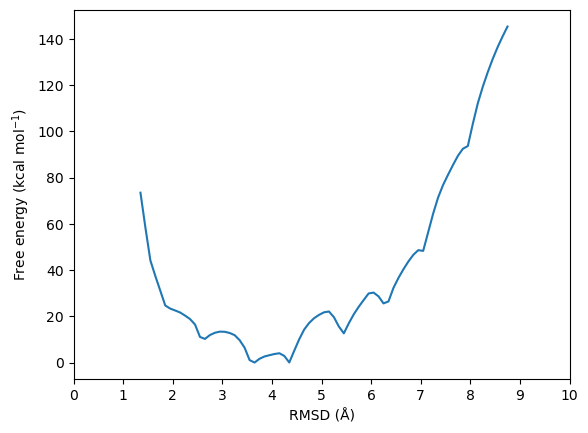

In [36]:
# Plot the data
sns.lineplot(x='Coor', y='Free', data=df1)

# Set plot title and labels
plt.xlabel('RMSD (Å)')
# Set x-ticks
plt.xticks(np.arange(0, 11, step=1))

plt.ylabel('Free energy (kcal mol$^{-1}$)')

# Show the plot
plt.show()

### `B2/trial9_param_FSC_terminal_finished/9dot24_k10_rmsd1_nvt_colv_int_atom`
Have NOT checked conformational change in VMD!

```sh
wham 0 10 100 0.01 310 0 meta.dat result.dat
```

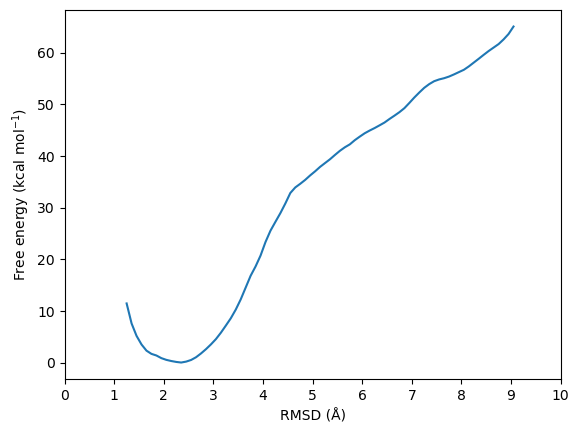

In [39]:
colv_fsc_k10_nvt_free_path = 'B2/trial9_param_FSC_terminal_finished/9dot24_k10_rmsd1_nvt_colv_int_atom/result.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_fsc_k10_nvt_free_df = (pd.read_csv(colv_fsc_k10_nvt_free_path, delim_whitespace=True, skiprows=1, 
                                        names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))

# Plot the data
sns.lineplot(x='Coor', y='Free', data=colv_fsc_k10_nvt_free_df)

# Set plot title and labels
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')

# Set x-ticks
plt.xticks(np.arange(0, 11, step=1))

# Show the plot
plt.show()

Is the minima at the equilibration RMSD? Plot RMSD timeseries for the equilibration step!

Overlay actual `colv` histograms!

## PyMBAR

### GitHub example

In [26]:
from pymbar import *

In [32]:
x_n, u_kn, N_k, s_n = testsystems.HarmonicOscillatorsTestCase().sample()

In [42]:
print(x_n, u_kn, N_k, s_n, sep='\n')

[0.17983009 1.56015641 0.93456035 ... 4.1012268  4.30912919 3.75133039]
[[1.61694305e-02 1.21704401e+00 4.36701520e-01 ... 8.41003065e+00
  9.28429719e+00 7.03623986e+00]
 [6.72678683e-01 3.13775206e-01 4.28234836e-03 ... 9.61760769e+00
  1.09503360e+01 7.56981893e+00]
 [6.62603701e+00 3.86924764e-01 2.27032331e+00 ... 8.83030816e+00
  1.06641552e+01 6.13431629e+00]
 [3.18134333e+01 8.29259823e+00 1.70641639e+01 ... 4.85080189e+00
  6.85527696e+00 2.25798944e+00]
 [1.16749585e+02 4.76226939e+01 7.51753622e+01 ... 8.19749258e-02
  7.64486854e-01 4.94692587e-01]]
[10 20 30 40 50]
[0 0 0 ... 4 4 4]


In [33]:
mbar = MBAR(u_kn, N_k)

In [29]:
results = mbar.compute_free_energy_differences()

In [34]:
A_kn = x_n # use position of harmonic oscillator as observable

In [35]:
results = mbar.compute_expectations(A_kn)

In [36]:
results

{'mu': array([0.33801446, 1.07260722, 1.95834631, 2.98231245, 3.95947617]),
 'sigma': array([0.24679134, 0.10182153, 0.07206547, 0.05243455, 0.02695643])}